<a href="https://colab.research.google.com/github/jonshiach/graphics-book/blob/main/jupyter-notebooks/2_Rasterising_lines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rasterising straight lines

**Inputs** A raster array $R$, pixel co-ordinates of the endpoints of a straight line $(x, y)$ and $(x_1, y_1)$ and the colour of the line defined by the RBG triplet $colour$.

**Output** A raster array $R$.

- Initialise $x \gets x_0$, $y \gets y_0$, $\Delta x \gets |x_1 - x|$, $\Delta y \gets |y_1 - y|$, $D \gets \Delta x - \Delta y$, $x_{step} \gets 1$ and $y_{step} \gets 1$
- If $x > x_1$ then
    - $x_{step} \gets -1$ 
- If $y > y_1$ then
    - $y_{step} \gets -1$  
- While true do
    - $R(y,x) \gets colour$
    - If $x = x_1$ and $y = y_1$ then
        - Terminate algorithm and return $R$
    - $E \gets 2D$
    - If $E \geq -\Delta y$ then
        - $x \gets x + x_{step}$ and $D \gets D - \Delta y$ 
    - If $E \leq \Delta x$ then
        - $y \gets y + y_{step}$ and $D \gets D + \Delta x$    

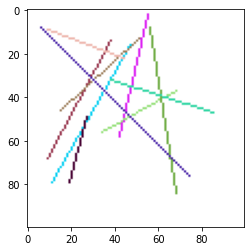

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def drawline(R, x0, y0, x1, y1, colour):
    x, y, dx, dy = x0, y0, abs(x1 - x0), abs(y1 - y0)
    D = dx - dy
    xstep, ystep = 1, 1
    if x0 > x1:
        xstep = -1
    if y0 > y1:
        ystep = -1

    while True:
        R[y, x, :] = colour
        if x == x1 and y == y1:
            return R
        E = 2 * D
        if E >= -dy:
            x += xstep
            D -= dy
        if E <= dx:
            y += ystep
            D += dx


def pixelcoords(x, y, Nx, Ny):
    xp = int(x * Nx)
    yp = int((1 - y) * Ny)
    return xp, yp


# Initialise raster array (Nx x Ny x 3 integer array of 255's)
Nx, Ny = 100, 100
R = 255 * np.ones((Ny, Nx, 3)).astype(int)

# Draw lines
nlines = 10
for _ in range(nlines):
  # Determine random endpoint co-ordinates and line colour
  x0, y0, x1, y1 = [np.random.rand() for _ in range(4)]
  colour = np.random.randint(0, 255, 3)

  # Convert endpoint co-ordinates to pixel co-ordinates
  x0, y0 = pixelcoords(x0, y0, Nx, Ny)
  x1, y1 = pixelcoords(x1, y1, Nx, Ny)
  R = drawline(R, x0, y0, x1, y1, colour)

# Plot raster
fig, ax = plt.subplots()
plt.imshow(R)
plt.show()